In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module

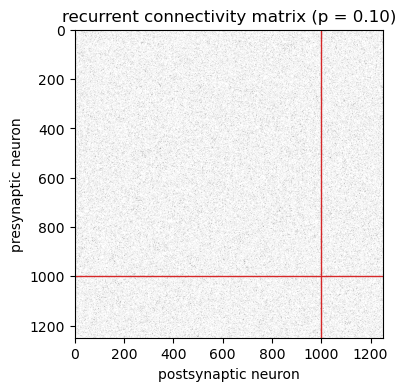

In [2]:
np.random.seed(20)  # reproducible connectivity + external events

# --- network size ---
N_E, N_I = 1000, 250
N = N_E + N_I  # neuron indices: 0,1,2 = excitatory, 3,4 = inhibitory

# --- random recurrent connectivity matrix, 30% pairwise probability, no autapses ---
P = 0.1
conn = np.random.rand(N, N) < P
np.fill_diagonal(conn, False)
pre_idx, post_idx = np.nonzero(conn)


fig, ax_c = plt.subplots(figsize=(4,4))
ax_c.imshow(conn, cmap='Greys', vmin=0, vmax=1)
ax_c.set_xlabel('postsynaptic neuron'); ax_c.set_ylabel('presynaptic neuron')
ax_c.set_title('recurrent connectivity matrix (p = %.2f)' % P)
for b in [N_E - 0.5]:
    ax_c.axhline(b, color='C3', lw=1); ax_c.axvline(b, color='C3', lw=1)


In [ ]:
brian.start_scope()

tstop = 1e3 # 500mss (in ms by default)
f_ext = 65. # Hz

eqs = '''
dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
dg_e/dt   = -g_e   / tau_e : siemens
dg_i/dt   = -g_i   / tau_i : siemens
dg_ext/dt = -g_ext / tau_e : siemens
'''

pop = brian.NeuronGroup(N, eqs, threshold='v>Vt', reset='v=Vr',
                         method='exponential_euler')
pop.v = El

is_exc_source = pre_idx < N_E
syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

# --- independent external excitatory events ---
ext_factors = [1. if i<N_E else 1.5 for i in range(N)]
ext_times =[
    np.cumsum(np.random.exponential(1e3/f_ext/f, int(f_ext*tstop))+1e-1)\
          for n, f in enumerate(ext_factors)
]
ext_input = brian.SpikeGeneratorGroup(N, 
                    np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                    np.concatenate(ext_times)*ms)

syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

mon    = brian.StateMonitor(pop, 'v',
                            record=np.concatenate([np.arange(4), N_E+np.arange(2)]))
spikes = brian.SpikeMonitor(pop)

brian.run(tstop*ms)



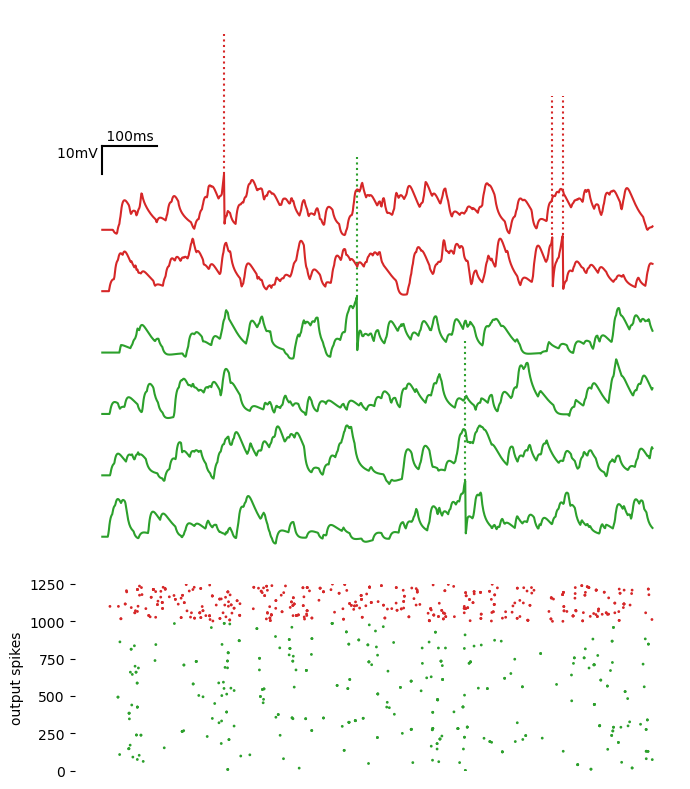

In [4]:
from plots import plot_with_spikes

def plot(mon, spikes):

    # --- plot: connectivity matrix, voltage traces, raster ---
    fig = plt.figure(figsize=(7, 8))
    gs = fig.add_gridspec(2, 1,
                          height_ratios=[3, 1])

    ax_v = fig.add_subplot(gs[0], frameon=False)
    for n in range(mon.v.shape[0]):
        plot_with_spikes(ax_v, mon, n, shift=n*22,
                         subsampling=10,
                         color='C2' if n<4 else 'C3')

    # show bar scale
    ax_v.plot([0,0], El/mV+(n+2)*20-np.arange(2)*10, 'k-')
    ax_v.plot([0,100], El/mV+(n+2)*20-np.zeros(2), 'k-')
    ax_v.annotate('10mV ', (0,El/mV+(n+2)*20), va='top', ha='right', xycoords='data')
    ax_v.annotate(' 100ms', (0,El/mV+(n+2)*20+2), xycoords='data')
    ax_v.axis('off')

    ax_r = fig.add_subplot(gs[1], sharex=ax_v, frameon=False)
    # we randomly subsample spikes if they are too numerous for display
    spike_subsampling = np.random.choice(np.arange(len(spikes.i)),
                                         np.min([10000, len(spikes.i)]))
    ax_r.scatter(spikes.t[spike_subsampling]/ms, spikes.i[spike_subsampling],
                 c=['C2' if i<N_E else 'C3' for i in spikes.i[spike_subsampling]], s=1)
    ax_r.set_ylabel('output spikes')
    ax_r.set_xticks([])
    ax_r.set_ylim([-1,N])

    plt.tight_layout()

plot(mon, spikes)